We want to predict PM2.5. It is a time dumy issue.

In [54]:
import pandas as pd 
import numpy as np 
import seaborn as sbn 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


In [55]:
# We first only focus on the Aotizhongxin location 
df = pd.read_csv("../data/raw/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
print(df.shape)
df.head()

(35064, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [56]:
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df.sort_values("datetime").reset_index(drop=True)
new_order = ['datetime', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']
df = df[new_order]
df.head()

,datetime,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2013-03-01 01:00:00,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [57]:
nan_percentage = (df.isna().mean() * 100).round(2)
print(f"Percentage of nan per feature : \n {nan_percentage}")

Percentage of nan per feature : 
 datetime    0.00
year        0.00
month       0.00
day         0.00
hour        0.00
PM2.5       2.64
PM10        2.05
SO2         2.67
NO2         2.92
CO          5.07
O3          4.90
TEMP        0.06
PRES        0.06
DEWP        0.06
RAIN        0.06
wd          0.23
WSPM        0.04
station     0.00
dtype: float64


There are some Nan Value, up to 5% for some features. We choose to use the Forward Fill in order to avoid data leakage. 

In [58]:
df_filled = df.ffill()

We use one hot encoder to go to a quantive value type for wd. We use drop_first = true to avoid circularity in case of using linear regression.

In [59]:
df_processed = pd.get_dummies(df_filled, columns =['wd'], dtype=int, drop_first=True)
df_processed.head()

,datetime,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
0,2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,...,1,0,0,0,0,0,0,0,0,0
1,2013-03-01 01:00:00,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,...,0,0,0,0,0,0,0,0,0,0
2,2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,...,1,0,0,0,0,0,0,0,0,0
3,2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,...,0,1,0,0,0,0,0,0,0,0
4,2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,...,0,0,0,0,0,0,0,0,0,0


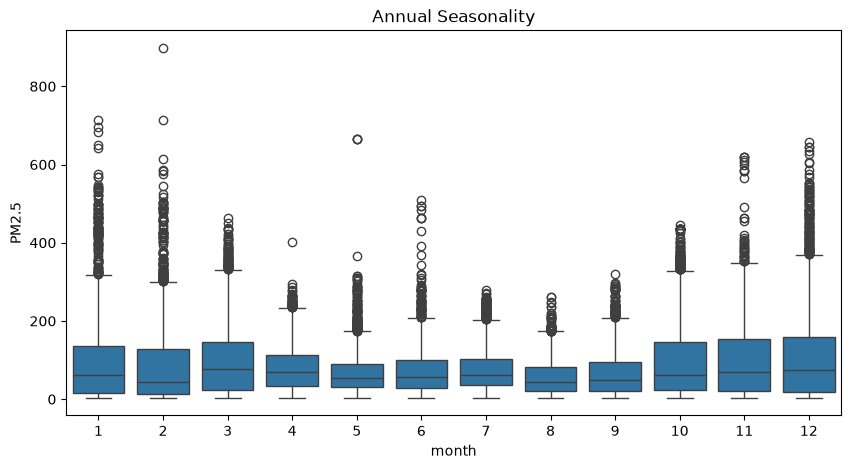

In [60]:
plt.figure(figsize=(10, 5))
sbn.boxplot(x='month', y='PM2.5', data=df_processed)
plt.title("Annual Seasonality")
plt.show()


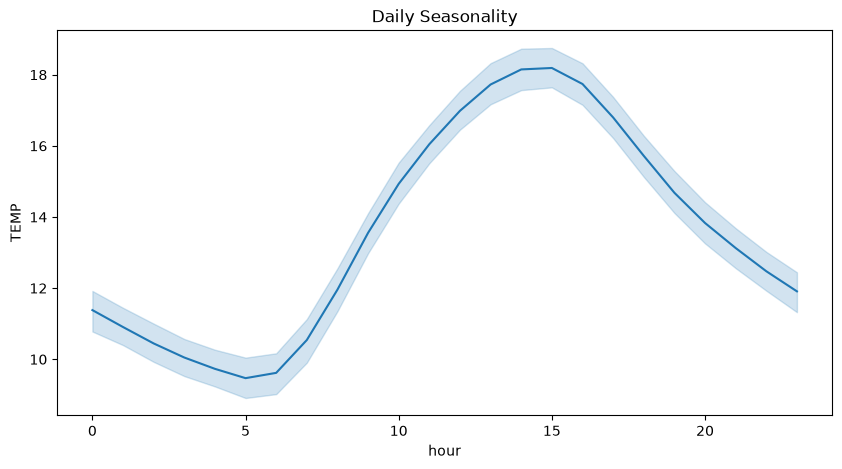

In [61]:
plt.figure(figsize=(10, 5))
# Affiche la température moyenne pour chaque heure de la journée
sbn.lineplot(x='hour', y='TEMP', data=df_processed)
plt.title("Daily Seasonality")
plt.show()


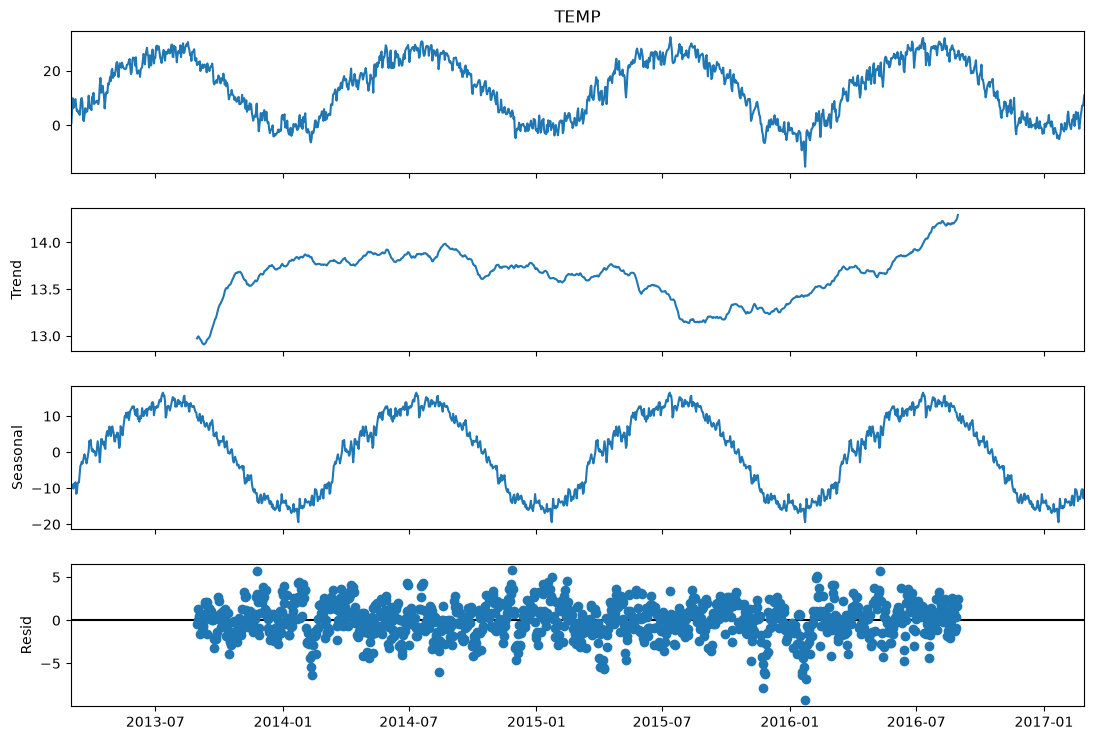

In [ ]:

# Attention, cette méthode est lourde. Il vaut mieux la faire sur les 
# moyennes journalières ou hebdomadaires pour y voir clair, ou sur 1 seule station.

# 1. On prend les moyennes par jour sur une station pour l'exemple
daily_data = df_processed.groupby(df_processed['datetime'].dt.date)['TEMP'].mean()

# 2. period = 365 day so we get the trend on the year
decompo = seasonal_decompose(daily_data.dropna(), model='additive', period=365)

# 3. On affiche les 4 graphiques (Original, Trend, Seasonal, Residuals)
fig = decompo.plot()
fig.set_size_inches(12, 8)
plt.show()


/var/folders/9d/xrd95x4d7rz8r6fr6p47l44h0000gn/T/ipykernel_2690/765387599.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.boxplot(x='month', y=colonne, data=df_processed, palette='viridis')
/var/folders/9d/xrd95x4d7rz8r6fr6p47l44h0000gn/T/ipykernel_2690/765387599.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.boxplot(x='month', y=colonne, data=df_processed, palette='viridis')
/var/folders/9d/xrd95x4d7rz8r6fr6p47l44h0000gn/T/ipykernel_2690/765387599.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.boxplot(x='month', y=colonne, data=df_processed, palette=

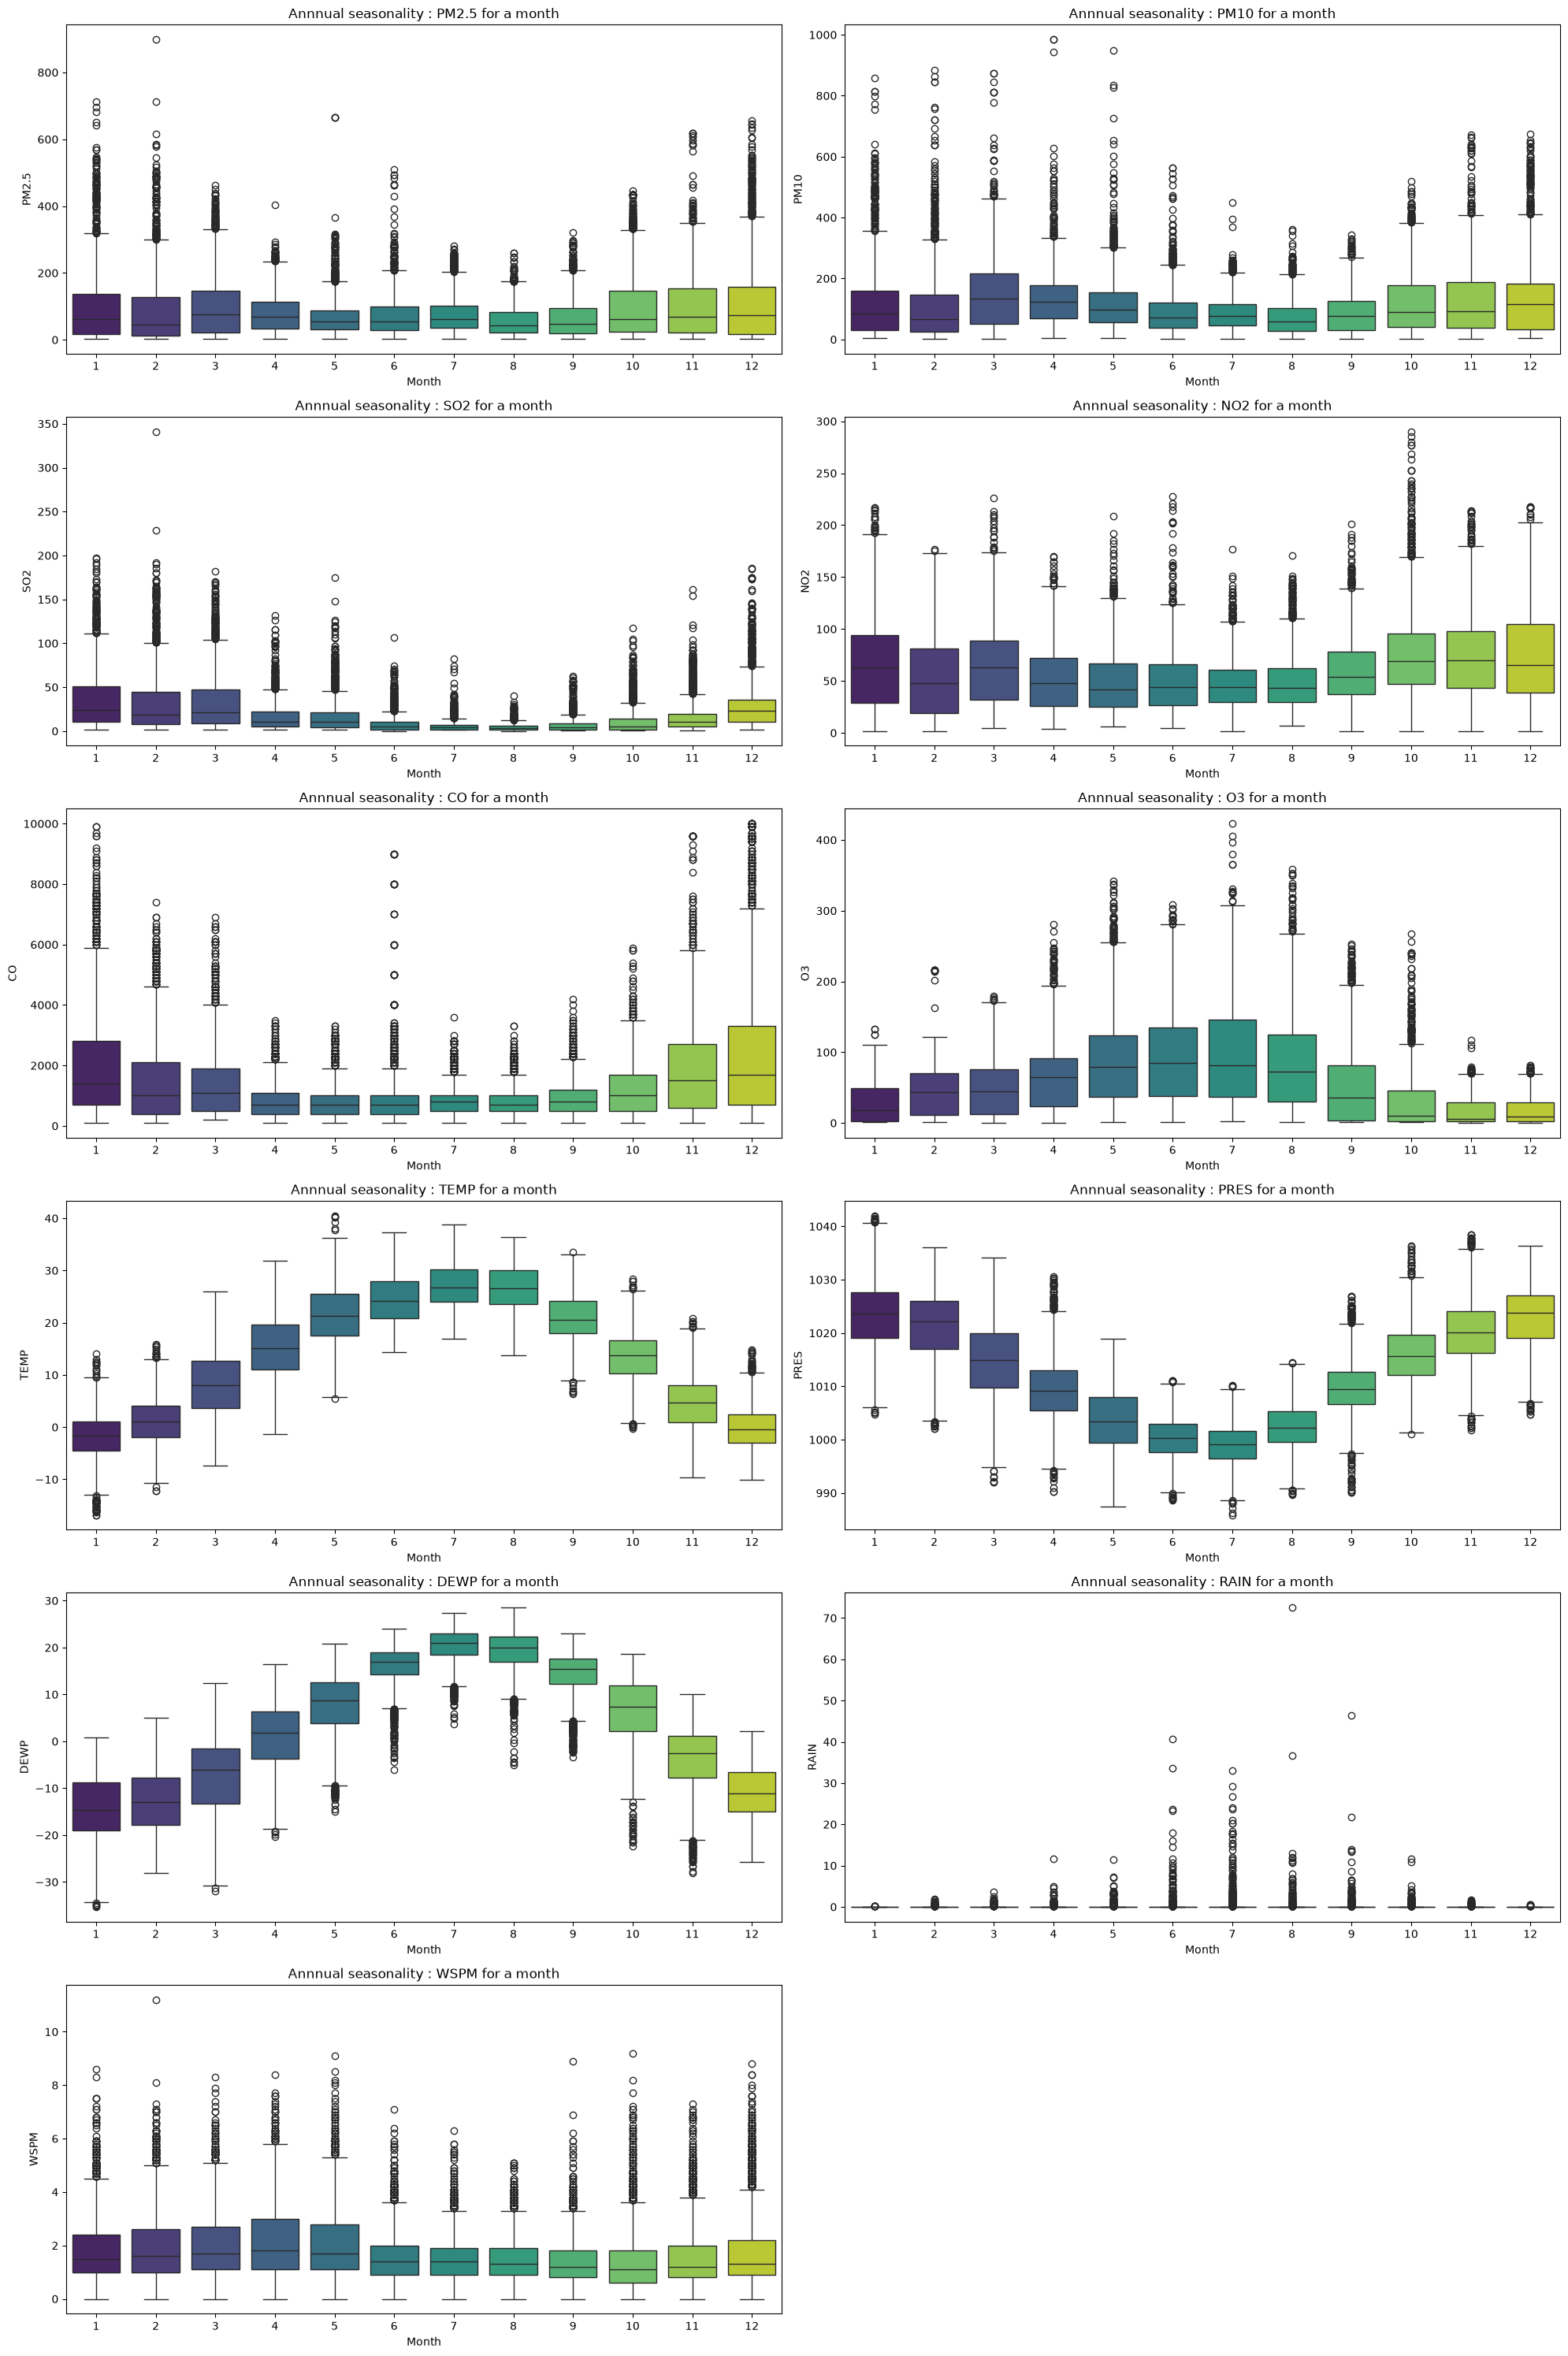

In [66]:

colonnes_a_etudier = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

plt.figure(figsize=(20, 30))

for i, colonne in enumerate(colonnes_a_etudier):
    plt.subplot(6, 2, i + 1)
    
    sbn.boxplot(x='month', y=colonne, data=df_processed, palette='viridis')
    
    plt.title(f"Annnual seasonality : {colonne} for a month")
    plt.xlabel("Month")
    plt.ylabel(colonne)

plt.tight_layout()
plt.show()


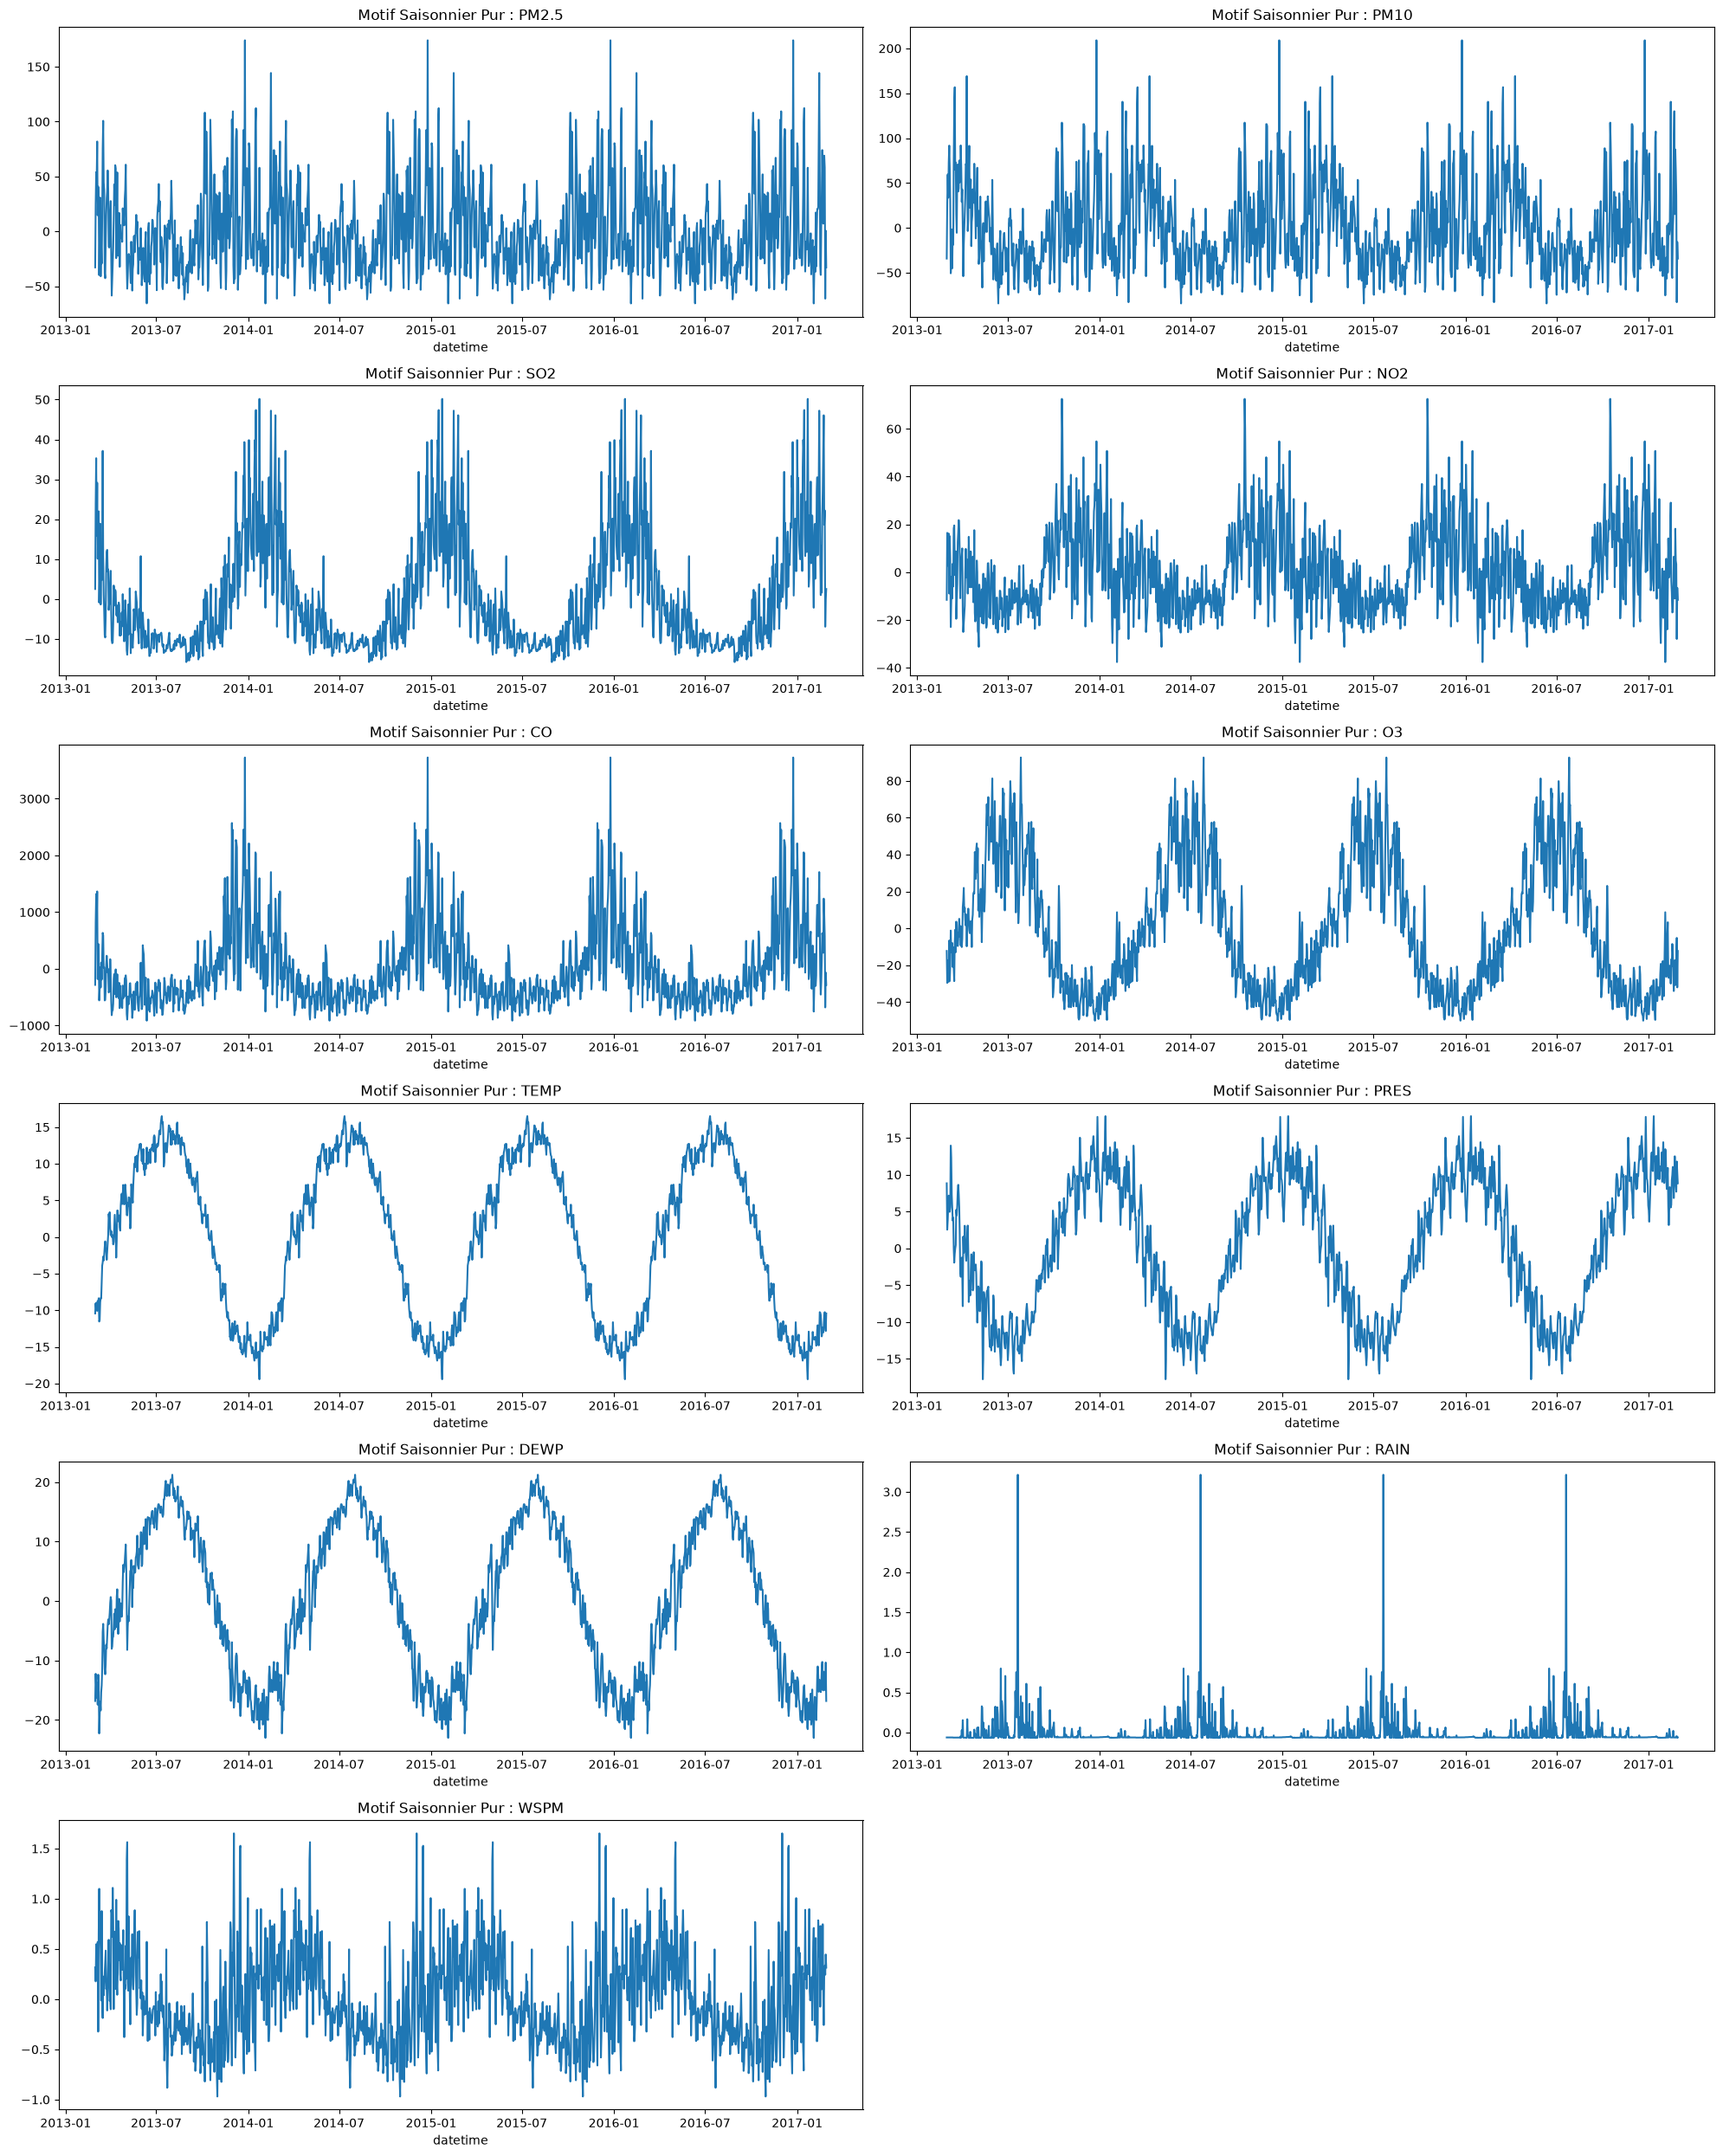

In [67]:
daily_data = df_processed.groupby(df_processed['datetime'].dt.date)[colonnes_a_etudier].mean()
daily_data = daily_data.dropna()
plt.figure(figsize=(20, 25))
for i, colonne in enumerate(colonnes_a_etudier):
    plt.subplot(6, 2, i + 1)
    
    # On décompose avec une période de 365 (une année)
    decompo = seasonal_decompose(daily_data[colonne], model='additive', period=365)
    
    # On ne trace QUE la composante saisonnière
    decompo.seasonal.plot(ax=plt.gca(), title=f"Motif Saisonnier Pur : {colonne}")
    
plt.tight_layout()
plt.show()

/var/folders/9d/xrd95x4d7rz8r6fr6p47l44h0000gn/T/ipykernel_2690/1307380827.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.boxplot(x='hour', y=colonne, data=df_processed, palette='viridis')
/var/folders/9d/xrd95x4d7rz8r6fr6p47l44h0000gn/T/ipykernel_2690/1307380827.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.boxplot(x='hour', y=colonne, data=df_processed, palette='viridis')
/var/folders/9d/xrd95x4d7rz8r6fr6p47l44h0000gn/T/ipykernel_2690/1307380827.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.boxplot(x='hour', y=colonne, data=df_processed, palette=

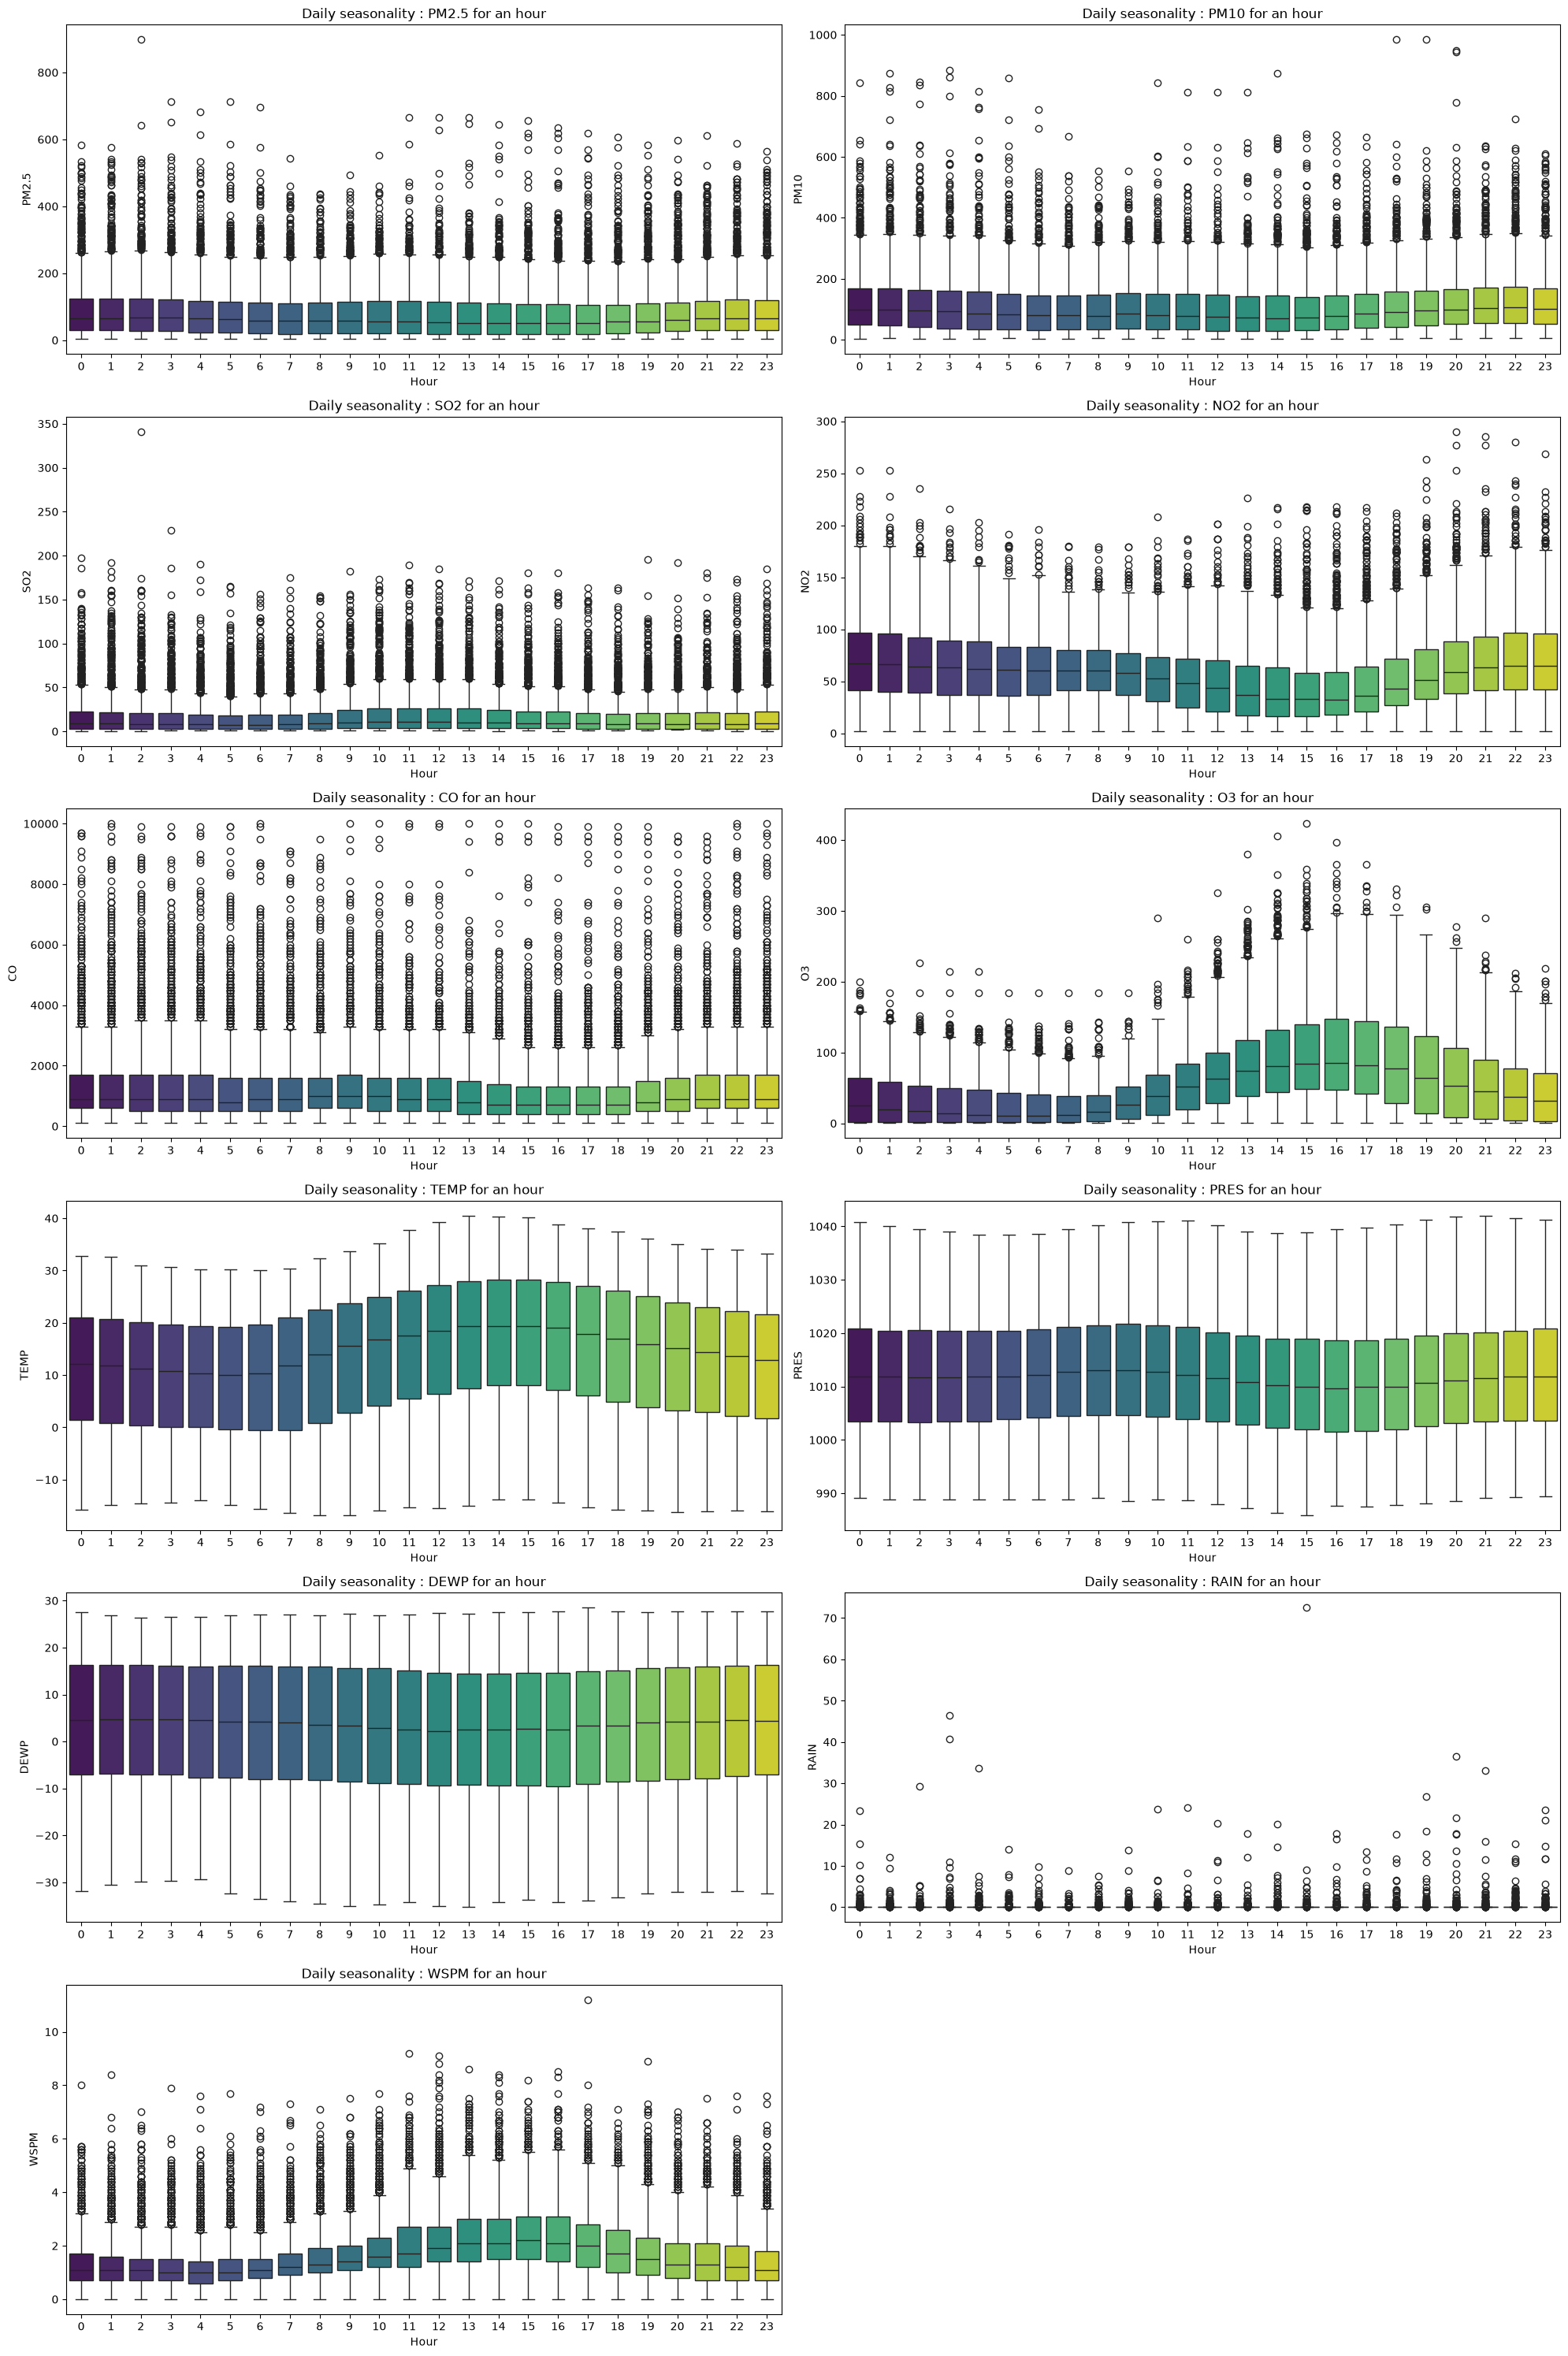

In [74]:

colonnes_a_etudier = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

plt.figure(figsize=(20, 30))

for i, colonne in enumerate(colonnes_a_etudier):
    plt.subplot(6, 2, i + 1)
    
    sbn.boxplot(x='hour', y=colonne, data=df_processed, palette='viridis')
    
    plt.title(f"Daily seasonality : {colonne} for an hour")
    plt.xlabel("Hour")
    plt.ylabel(colonne)

plt.tight_layout()
plt.show()


In [ ]:
# as seasonality exist, we want to keep month and hour as feature
# we want to circle the hour and month so the model understant that 11 pm is juste beofre 12 am
# we want the model to be able to understant the cycle of the hour or month 

df_processed['hour_sin'] = np.sin(2 * np.pi * df_processed['hour'] / 24.0)
df_processed['hour_cos'] = np.cos(2 * np.pi * df_processed['hour'] / 24.0)

df_processed['month_sin'] = np.sin(2 * np.pi * df_processed['month'] / 12.0)
df_processed['month_cos'] = np.cos(2 * np.pi * df_processed['month'] / 12.0)